# Model Training

## Objective

The objective of this stage is to train and evaluate multiple machine learning classification models for predicting PCOS risk using clinical and lifestyle features. The models will be compared based on predictive performance, robustness, and interpretability to determine their suitability within a healthcare context.

In [3]:
# Import required libraries
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [4]:
# Load cleaned dataset
df = pd.read_csv("../data/processed/pcos_cleaned.csv")

In [7]:

# Separate Features and Target Variable

# Separate input features and target variable
X = df.drop(columns=["PCOS (Y/N)"])
y = df["PCOS (Y/N)"]


# Train-Test Split

from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets
# stratify=y helps preserve class distribution

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



# Convert Object Columns to Numeric

# Convert object columns into numeric values
# Invalid values will temporarily become NaN

X_train["II    beta-HCG(mIU/mL)"] = pd.to_numeric(
    X_train["II    beta-HCG(mIU/mL)"],
    errors="coerce"
)

X_test["II    beta-HCG(mIU/mL)"] = pd.to_numeric(
    X_test["II    beta-HCG(mIU/mL)"],
    errors="coerce"
)

X_train["AMH(ng/mL)"] = pd.to_numeric(
    X_train["AMH(ng/mL)"],
    errors="coerce"
)

X_test["AMH(ng/mL)"] = pd.to_numeric(
    X_test["AMH(ng/mL)"],
    errors="coerce"
)

print("Object columns converted successfully.")



# Handle Remaining Missing Values

# Replace remaining missing values using median imputation
# Median is less sensitive to outliers

X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_test.median())

print("Remaining missing values handled successfully.")



# Feature Scaling

from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Scale training and testing features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Object columns converted successfully.
Remaining missing values handled successfully.
Feature scaling completed successfully.


In [1]:
# Import Machine Learning Models

# Logistic Regression:
# A simple and interpretable linear model often used in healthcare research
from sklearn.linear_model import LogisticRegression

# Decision Tree:
# A tree-based model that makes decisions using feature-based splits
from sklearn.tree import DecisionTreeClassifier

# Random Forest:
# An ensemble model that combines multiple decision trees for better accuracy and robustness
from sklearn.ensemble import RandomForestClassifier

# Support Vector Machine (SVM):
# A model that attempts to separate classes using optimal decision boundaries
from sklearn.svm import SVC


# Import Evaluation Metrics

# Accuracy:
# Measures overall prediction correctness
from sklearn.metrics import accuracy_score

# Precision:
# Measures how many predicted PCOS cases were actually correct
from sklearn.metrics import precision_score

# Recall:
# Measures how many actual PCOS cases were successfully identified
from sklearn.metrics import recall_score

# F1-Score:
# Balances precision and recall into a single metric
from sklearn.metrics import f1_score

# Classification Report:
# Provides a detailed summary of model performance
from sklearn.metrics import classification_report

# Confusion Matrix:
# Shows correct and incorrect classifications
from sklearn.metrics import confusion_matrix

# ROC-AUC:
# Measures the model's ability to distinguish between classes
from sklearn.metrics import roc_auc_score



# Import Visualisation Libraries

# Matplotlib:
# Used for creating graphs and plots
import matplotlib.pyplot as plt

# Seaborn:
# Used for cleaner statistical visualisations
import seaborn as sns

## Logistic Regression

Logistic Regression was selected as the baseline classification model due to its simplicity, interpretability, and widespread use in healthcare prediction tasks. The model estimates the probability of PCOS occurrence based on relationships between clinical and lifestyle variables.

In [8]:

# Logistic Regression Model Training


# Create Logistic Regression model
# random_state=42 ensures consistent and reproducible results
log_model = LogisticRegression(random_state=42)

# Train the model using the scaled training data
# The model learns relationships between the features and PCOS outcomes
log_model.fit(X_train_scaled, y_train)

# Generate predictions using the testing dataset
# The model predicts whether patients are likely to have PCOS
y_pred_log = log_model.predict(X_test_scaled)

# Display confirmation message
print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [9]:

# Logistic Regression Evaluation

# Calculate evaluation metrics

log_accuracy = accuracy_score(y_test, y_pred_log)
log_precision = precision_score(y_test, y_pred_log)
log_recall = recall_score(y_test, y_pred_log)
log_f1 = f1_score(y_test, y_pred_log)

# Display results

print("Accuracy:", log_accuracy)
print("Precision:", log_precision)
print("Recall:", log_recall)
print("F1-Score:", log_f1)

Accuracy: 0.8807339449541285
Precision: 0.8108108108108109
Recall: 0.8333333333333334
F1-Score: 0.821917808219178


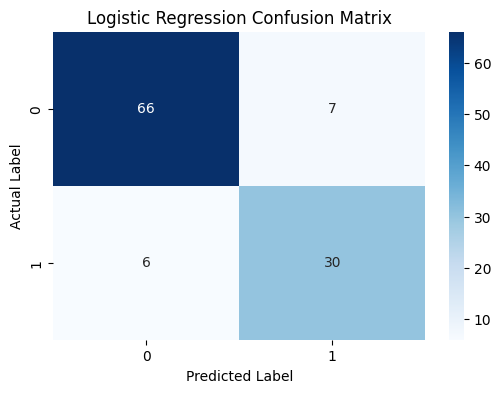

In [10]:

# Logistic Regression Confusion Matrix

# Generate confusion matrix
cm_log = confusion_matrix(y_test, y_pred_log)

# Create heatmap visualisation
plt.figure(figsize=(6,4))

sns.heatmap(
    cm_log,
    annot=True,
    fmt='d',
    cmap='Blues'
)

# Add labels and title
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Logistic Regression Confusion Matrix")

# Display plot
plt.show()

## Decision Tree Classifier

Decision Trees were selected because they can model nonlinear relationships between clinical and lifestyle variables associated with PCOS. Unlike Logistic Regression, Decision Trees generate hierarchical decision rules, allowing more complex feature interactions to be captured during classification.

In [11]:

# Decision Tree Model Training

# Create Decision Tree model
# random_state=42 ensures reproducible results

dt_model = DecisionTreeClassifier(random_state=42)

# Train the model using the scaled training data
dt_model.fit(X_train_scaled, y_train)

# Generate predictions on the testing dataset
y_pred_dt = dt_model.predict(X_test_scaled)

# Display confirmation message
print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [12]:

# Decision Tree Evaluation

# Calculate evaluation metrics

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

# Display results

print("Accuracy:", dt_accuracy)
print("Precision:", dt_precision)
print("Recall:", dt_recall)
print("F1-Score:", dt_f1)

Accuracy: 0.8899082568807339
Precision: 0.8529411764705882
Recall: 0.8055555555555556
F1-Score: 0.8285714285714286


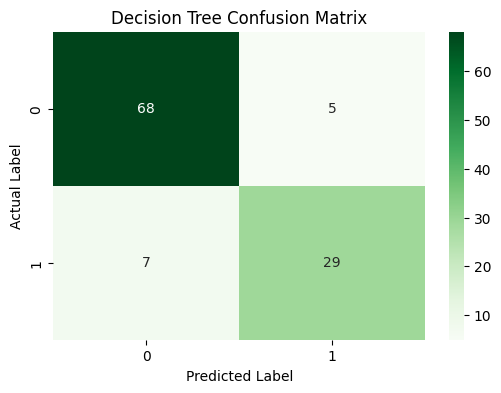

In [13]:

# Decision Tree Confusion Matrix

# Generate confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

# Create heatmap visualisation
plt.figure(figsize=(6,4))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Greens'
)

# Add labels and title
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Decision Tree Confusion Matrix")

# Display plot
plt.show()